# Scenario B2: Multiple Suppliers — With REC (Net Generators)

**Description:** Two suppliers with a shared cross-supplier REC. All 9 participants
belong to REC_01, which performs proportional energy sharing before each supplier
handles its balancing obligations independently. Prosumers are modelled as
**net generators** (RES only, no local load).

**Participant–supplier assignment (homogeneous BGs):**
| Supplier / BG | Participants |
|---|---|
| SUP_A / BG_A (Consumers) | consumer_001 (Local Authority) · consumer_002 (Apartment) · consumer_003 (Apartment) · consumer_004 (Hot Water Boiler) · consumer_005 (Bank) · consumer_006 (Household) |
| SUP_B / BG_B (Prosumers) | prosumer_001 (Fire Station) · prosumer_002 (Household) · prosumer_003 (Household) |

**Configuration:**
| Parameter | Value |
|---|---|
| Suppliers | 2 — SUP_A, SUP_B |
| Balancing Groups | 2 — BG_A (all consumers), BG_B (all prosumers) |
| RECs | 1 — REC_01 (all 9 members, proportional sharing) |
| Prosumer type | **Net generator** (RES only, no local load) |
| REC incentives | Shared energy: 0.01 €/kWh · Self-consumption: 0.015 €/kWh |
| Settlement basis | Corrected meter readings after REC sharing |
| Battery | None |

**Research role:** Tests whether a cross-supplier community REC can capture
sharing benefits even when participants belong to competing suppliers with
independently managed balancing groups.

**Comparison pairs (net-generator track):**
- B2 vs B1 → incremental REC value under multi-supplier
- B2 vs A2 → single vs multi-supplier with equivalent REC structure
- B2 vs B2-forecasts → impact of explicit forecast scheduling on imbalance costs

## 1. Import Dependencies
Import the EnergyMarketOperations class which handles the complete market simulation pipeline.

In [1]:
from energy_market_operations import EnergyMarketOperations

## 2. Initialize Pipeline
Load the scenario configuration from JSON and create the pipeline instance. The config specifies participants, suppliers, market prices, and network topology.

In [2]:
CONFIG_FILE = "B2_multiple_suppliers_with_rec(net generators).json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="B2")

## 3. Run Full Pipeline
Execute the complete market simulation:
1. **Day-Ahead Market** - Schedule energy positions based on DA forecasts (per BG)
2. **Intra-Day Market** - Adjust positions with updated ID forecasts (per BG)
3. **REC Settlement** - Proportional energy sharing within community
4. **Balancing Market** - Settle imbalances at dual pricing (per BG)
5. **Supplier Billing** - Calculate final costs per participant

In [3]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: B2
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SCENARIO: B2
  System  : Multiple Suppliers with REC - Scenario B2
  Period  : 2016-01-01 → 2016-12-31
  Suppliers    : 2
  Prosumers    : 3
  Consumers    : 6
  RECs         : 1  →  has_rec = True
  Battery      : False
✓ Prices loaded: (35136, 5)  from prices.csv
✓ Load actual : (35136, 153)
✓ RES actual  : (35136, 27)
✓ Load forecast DA: (35136, 6)
✓ RES  forecast DA: (35136, 3)
✓ Load forecast ID: (35136, 6)
✓ RES  forecast ID: (35136, 3)
✓ DA market: (70272, 8)
✓ ID market : (70272, 19)
⚠ Battery optimization: skipped (no battery in config)
✓ REC settlement: 1 REC(s) processed
✓ Balancing market: (70272, 31)
✓ Customer billing: (316224, 12)  (9 customers)
✓ Monthly aggregation: (24, 27)
✓ Profit/loss calculated

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 4. Financial Summary
Display aggregated financial results including total revenues, costs, and profit/loss for each supplier.

In [4]:
pipe.summary()


  ANNUAL FINANCIAL SUMMARY – B2

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €        0.00
      Balancing Rewards   : €      206.03
      Retail Sales        : €   21,123.93
      ────────────────────────────────────────────
      Total Revenue       : €   21,329.95

    COSTS:
      Market Purchases    : €    4,749.35
      Balancing Penalties  : €    1,472.87
      Retail Purchases     : €        0.00
      ────────────────────────────────────────────
      Total Costs          : €    6,222.22

    PROFIT/LOSS:
      Annual Total         : €   15,107.73
      Monthly Average      : €    1,258.98

    IMBALANCE:
      System Position      : LONG
      Total Imbalance      :       -43.23 MWh
      BG Actual Position   :       105.09 MWh
      BG Forecast Position :       148.33 MWh

    REC SHARING:
      Shared Energy        :        43.24 MWh

  SUP_B (Supplier B):

    REVENUES:
      Energy Market Sales : €    1,568.91
      Balancing Rewards   : €    1,465.3

## 5. Financial Visualization
Plot breakdown of revenues and costs by category (DA purchases, ID adjustments, balancing costs, customer sales).

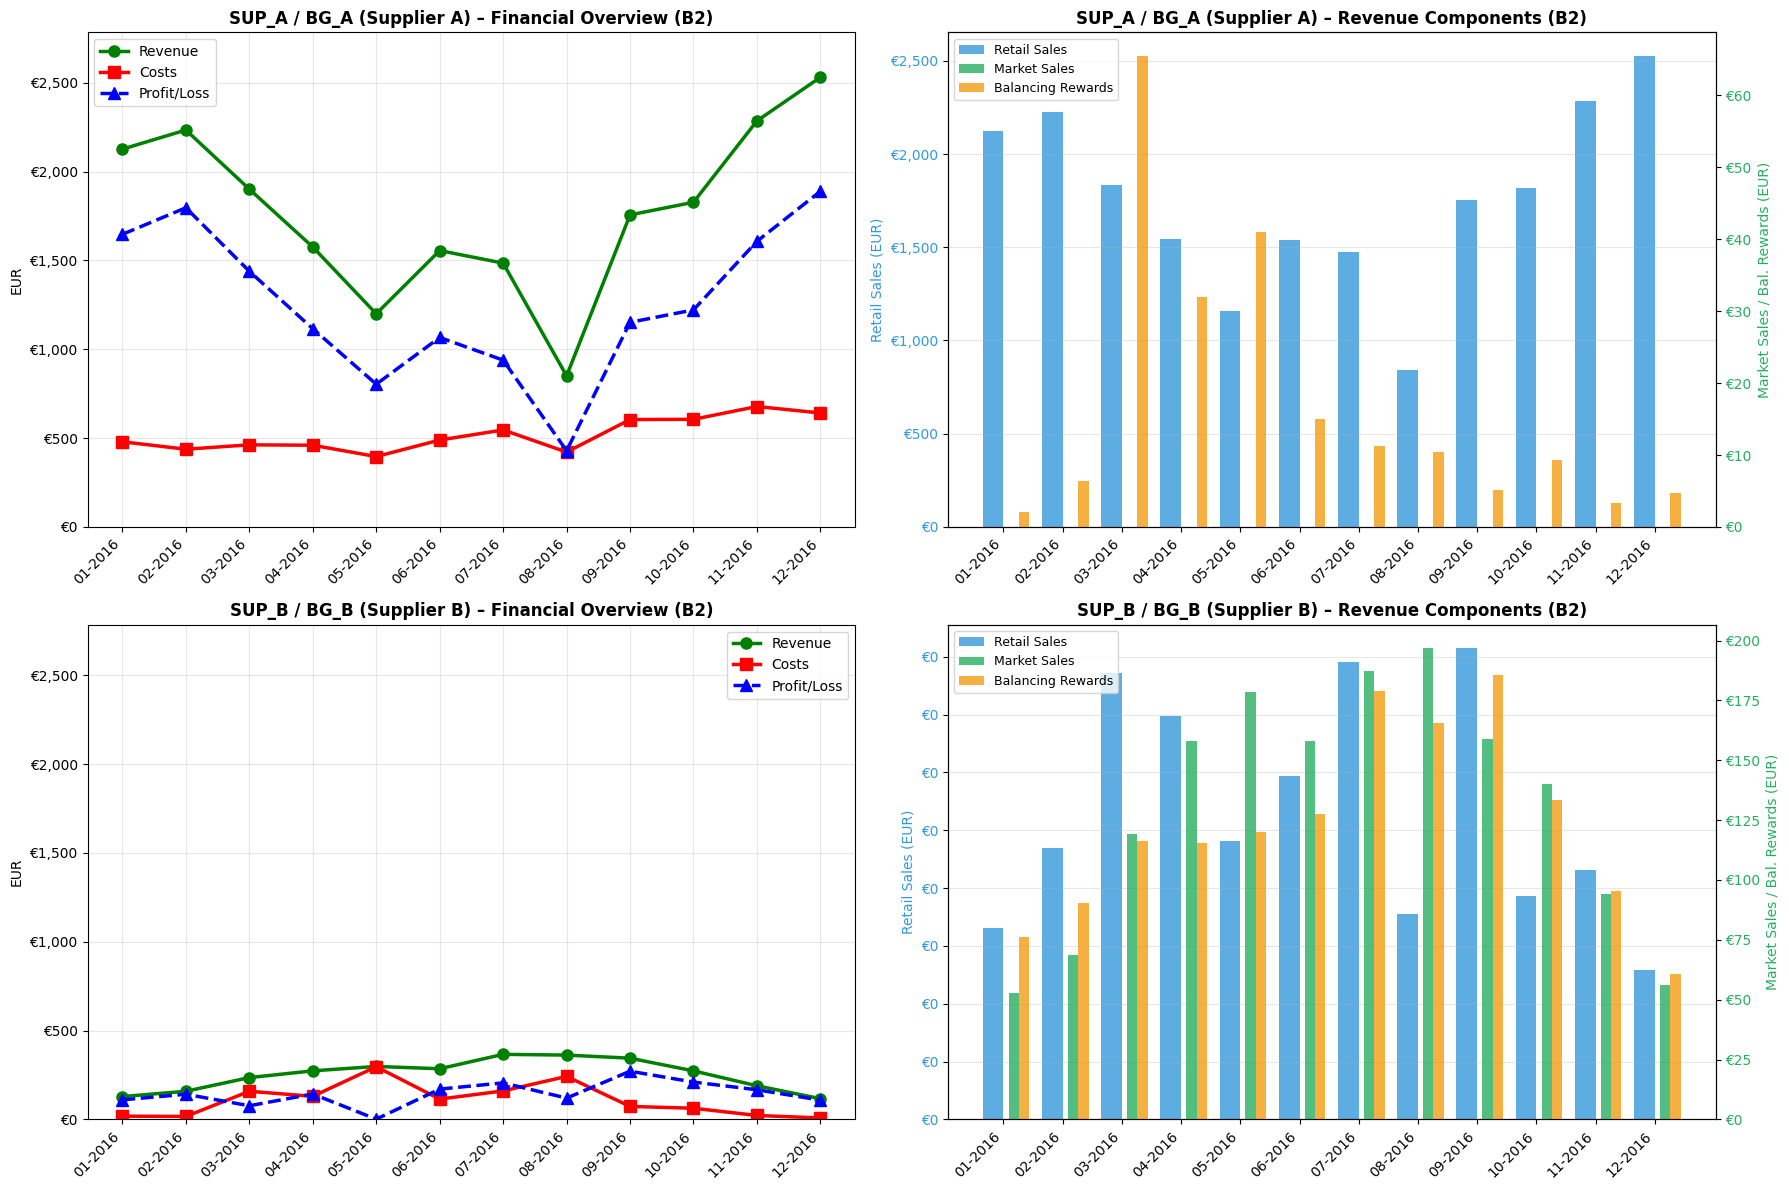

In [5]:
pipe.plot_financials()

## 6. Imbalance Analysis
Visualize system imbalances over time showing the difference between scheduled positions and actual metered values.

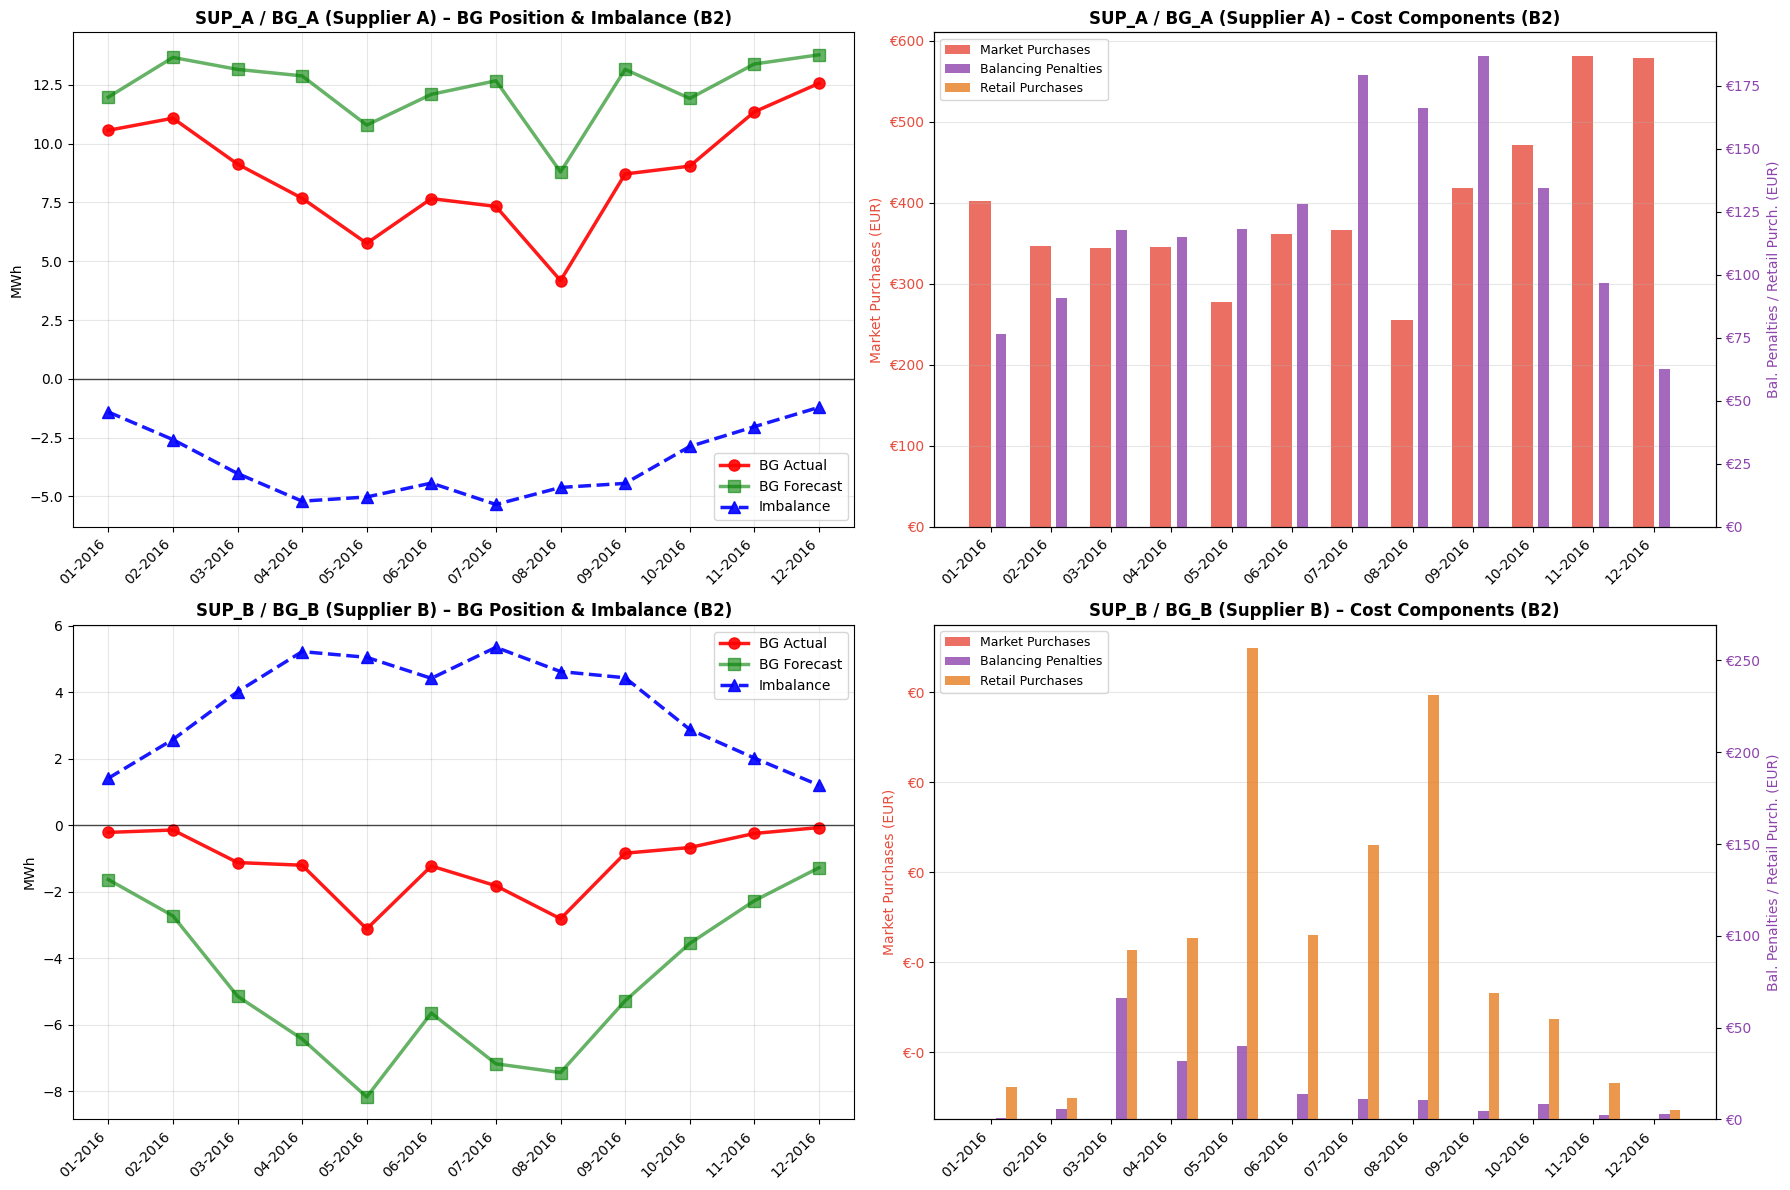

In [6]:
pipe.plot_imbalances()

## 7. REC + Supplier Analysis
Display total energy shared within the REC and compare supplier performance.

In [7]:
print(f"Total Shared Energy: {pipe.es_monthly_analysis_df['internal_shared_energy_mwh'].sum():,.2f} MWh")
pipe.es_monthly_analysis_df.groupby('supplier_id').agg({
    'profit_loss_eur': 'sum',
    'internal_shared_energy_mwh': 'sum'
})

Total Shared Energy: 86.47 MWh


,profit_loss_eur,internal_shared_energy_mwh
supplier_id,,
SUP_A,15107.733500,43.235693
SUP_B,1728.869073,43.235693
